In [2]:
import sys
import os
# Get the current working directory (where the notebook is running)
current_dir = os.getcwd()
# Go up one level to project root (adjust based on your structure)
project_root = os.path.dirname(current_dir)
sys.path.insert(0, project_root)

In [3]:
from pathlib import Path
from src.analyze.GMM_PCA_filter import XPSFilter
from src.analyze.PCA_normalizing import XPSAggregator

In [4]:
Result_folder = Path(r"C:\Users\ab177\Desktop\diffraction_results\1013longccl4")
process_dir = Result_folder / 'analysis_logic_test' / 'results'
output_dir = Result_folder / 'analysis_logic_test' / 'filteredGMM'

Safety Check [pass1]: Removed 128 rows containing NaN values.


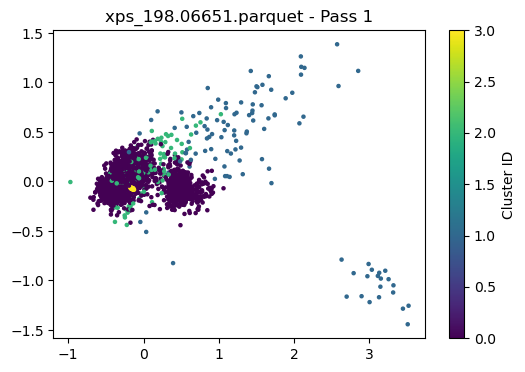

cluster_pass1
0    88.099106
1     4.589764
2     4.264825
3     3.046304
Name: proportion, dtype: float64


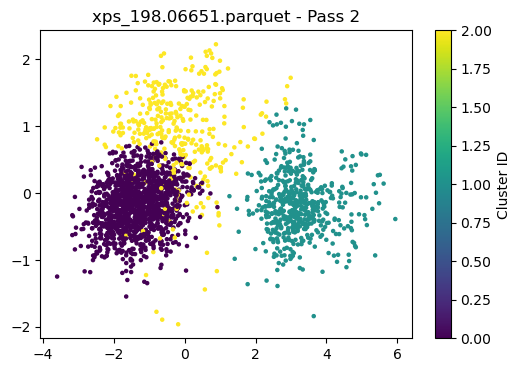

cluster_pass2
0    58.183495
1    25.265099
2    16.551406
Name: proportion, dtype: float64

Final retention: 2169/2590 (83.7%)


In [10]:
filter = XPSFilter(n_pca=4)
# filter.cluster_size = 15
# filter.gmmtype = 'tied'
# filteredfile = filter.process_with_manual_filter(process_dir / 'xps_198.09799.parquet')
filteredfile = filter.process_with_manual_filter(process_dir / 'xps_198.06651.parquet', output_dir)

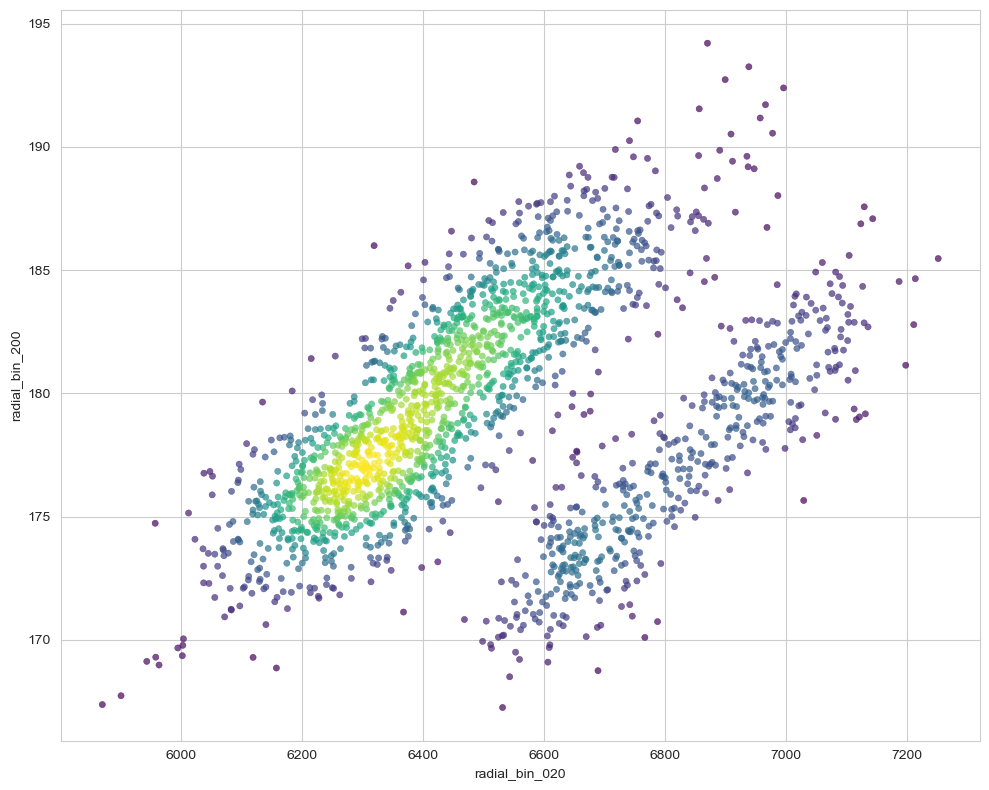

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

sns.set_style("whitegrid")
x = filteredfile["radial_bin_020"]
y = filteredfile["radial_bin_200"]
#y = df["center_y"]


mask = ~np.isnan(x) & ~np.isnan(y)
x_valid = x[mask]
y_valid = y[mask]
kde = gaussian_kde(np.vstack([x_valid, y_valid]))
density = kde(np.vstack([x_valid, y_valid]))

fig, ax = plt.subplots(figsize=(10, 8))
scatter = sns.scatterplot(
    x=x_valid,
    y=y_valid,
    c=density,  
    cmap="viridis",  # viridis/plasma/inferno
    s=20,  
    alpha=0.7,  
    edgecolor=None,  
    ax=ax
)
plt.tight_layout()
plt.show()

In [9]:
filter = XPSFilter(n_pca=4)
filter.auto_batch_filter(process_dir,output_dir, 4, 3, 10, 10)
# GMM cluster number1, number2, threshold1, threshold2.

Safety Check [pass1]: Removed 128 rows containing NaN values.
File xps_198.00505.parquet: Retained 1935 samples (78.7%)
File xps_198.00505.parquet: Largest cluster size after pass 2: 1474
Safety Check [pass1]: Removed 119 rows containing NaN values.
File xps_198.02004.parquet: Retained 2008 samples (79.1%)
File xps_198.02004.parquet: Largest cluster size after pass 2: 1492
Safety Check [pass1]: Removed 85 rows containing NaN values.
File xps_198.02754.parquet: Retained 1823 samples (76.3%)
File xps_198.02754.parquet: Largest cluster size after pass 2: 1465
Safety Check [pass1]: Removed 101 rows containing NaN values.
File xps_198.03503.parquet: Retained 1966 samples (79.0%)
File xps_198.03503.parquet: Largest cluster size after pass 2: 1513
Safety Check [pass1]: Removed 112 rows containing NaN values.
File xps_198.04253.parquet: Retained 2086 samples (83.8%)
File xps_198.04253.parquet: Largest cluster size after pass 2: 1195
Safety Check [pass1]: Removed 95 rows containing NaN values.


In [12]:
norm_dir = Result_folder / 'analysis_logic_test' / 'stats'
normalizer = XPSAggregator(norm_dir, 720)
normalizer.aggregate_directory(output_dir,60,200,[1],'minor')

Keeping 461 rows from clusters [1] (discarded 1474 ).
Aggregated auto_filtered_xps_198.00505.parquet: 461 frames.
Keeping 516 rows from clusters [1] (discarded 1492 ).
Aggregated auto_filtered_xps_198.02004.parquet: 516 frames.
Keeping 358 rows from clusters [1] (discarded 1465 ).
Aggregated auto_filtered_xps_198.02754.parquet: 358 frames.
Keeping 453 rows from clusters [1] (discarded 1513 ).
Aggregated auto_filtered_xps_198.03503.parquet: 453 frames.
Keeping 556 rows from clusters [1] (discarded 1530 ).
Aggregated auto_filtered_xps_198.04253.parquet: 556 frames.
Keeping 366 rows from clusters [1] (discarded 1883 ).
Aggregated auto_filtered_xps_198.04852.parquet: 366 frames.
Keeping 518 rows from clusters [1] (discarded 1495 ).
Aggregated auto_filtered_xps_198.05302.parquet: 518 frames.
Keeping 390 rows from clusters [1] (discarded 1499 ).
Aggregated auto_filtered_xps_198.05751.parquet: 390 frames.
Keeping 523 rows from clusters [1] (discarded 1568 ).
Aggregated auto_filtered_xps_198.0